# SimilarWeb Transformed Data — Detailed Description

This notebook profiles the **SimilarWeb** sample after it has been run through the *Innovation Lab
Agentic Commerce* pipeline. The data is a **star schema** of skincare AI-recommendation activity on
ChatGPT (one market, **January 2026**), stored as 7 Parquet tables in
`data/similarweb_transformed_data/`.

**Pipeline, in one paragraph.** Raw SimilarWeb search turns land in `fact_ai_search_turn`. For each
turn the pipeline extracts the skincare *entities* mentioned (`fact_ai_recommendation`) and decomposes
each entity into standardised *concept characteristics* (`fact_ai_concept`). Two classifiers tag every
turn with a **purchase-funnel stage** (`fact_ai_funnel` → `dim_ai_funnel`) and one or more **topics**
(`fact_ai_topic` → `dim_ai_topic`).

### Observed entity-relationship diagram
```mermaid
erDiagram
    fact_ai_search_turn ||--o{ fact_ai_recommendation : "message_id"
    fact_ai_recommendation ||--o{ fact_ai_concept : "recommendation_id = fact_id"
    fact_ai_search_turn ||--|| fact_ai_funnel : "message_id (1 stage/turn)"
    dim_ai_funnel ||--o{ fact_ai_funnel : "funnel_id"
    fact_ai_search_turn ||--o{ fact_ai_topic : "message_id (question/answer)"
    fact_ai_search_turn ||--o{ fact_ai_topic : "session_id (session)"
    dim_ai_topic ||--o{ fact_ai_topic : "topic_id"
```

> **Note — schema vs. the provided doc.** The data dictionary lists `fact_ai_concept.message_id`, but
> the actual file links concepts to **recommendations** via `fact_id = recommendation_id` (verified
> below at 100%). `mention_type` values are `requested` / `recommended` (not `request`/`recommendation`),
> and `fact_ai_funnel` stores **one assigned stage + score per turn** rather than a score per stage.


## Setup — load every table

In [3]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

DATA = Path("../data/similarweb_transformed_data")

TABLES = {p.stem: pd.read_parquet(p) for p in sorted(DATA.glob("*.parquet"))}
search_turn   = TABLES["fact_ai_search_turn"]
recommendation = TABLES["fact_ai_recommendation"]
concept       = TABLES["fact_ai_concept"]
funnel        = TABLES["fact_ai_funnel"]
dim_funnel    = TABLES["dim_ai_funnel"]
topic         = TABLES["fact_ai_topic"]
dim_topic     = TABLES["dim_ai_topic"]

print(f"loaded {len(TABLES)} tables:")
for name, df in TABLES.items():
    print(f"  {name:24} {df.shape[0]:>8,} rows x {df.shape[1]} cols")

loaded 7 tables:
  dim_ai_funnel                   7 rows x 4 cols
  dim_ai_topic                   34 rows x 2 cols
  fact_ai_concept           181,827 rows x 4 cols
  fact_ai_funnel             39,541 rows x 3 cols
  fact_ai_recommendation     39,879 rows x 6 cols
  fact_ai_search_turn        39,541 rows x 8 cols
  fact_ai_topic              83,704 rows x 3 cols


## 1 · Schema at a glance
| Table | Grain (one row per…) | Key | Links to |
|-------|----------------------|-----|----------|
| `fact_ai_search_turn` | user↔LLM **turn** | `message_id` (PK) | the spine of the model |
| `fact_ai_recommendation` | **entity** named in a turn | `recommendation_id` (PK) | `message_id` → search_turn |
| `fact_ai_concept` | one **characteristic** of an entity | (`fact_id`,`concept_name`,`concept_value`) | `fact_id` → recommendation |
| `fact_ai_funnel` | **turn** | `message_id` | `funnel_id` → dim_ai_funnel |
| `dim_ai_funnel` | funnel **stage** | `funnel_id` (PK) | — |
| `fact_ai_topic` | **turn×scope** (question/answer/session) | (`message_id`,`message_type`,`topic_id`) | `topic_id` → dim_ai_topic |
| `dim_ai_topic` | **topic** | `topic_id` (PK) | — |

In [4]:
def profile(df, name):
    info = pd.DataFrame({
        "dtype":  df.dtypes.astype(str),
        "nulls":  df.isna().sum(),
        "null_%": (df.isna().mean() * 100).round(1),
        "n_unique": [df[c].nunique() if df[c].apply(lambda v: not isinstance(v, (list, np.ndarray))).all()
                     else "list/array" for c in df.columns],
    })
    print(f"### {name}  —  {len(df):,} rows x {df.shape[1]} cols")
    print(info.to_string())
    print()

for name, df in TABLES.items():
    profile(df, name)

### dim_ai_funnel  —  7 rows x 4 cols
              dtype  nulls  null_%    n_unique
funnel_id     int64      0     0.0           7
funnel_name     str      0     0.0           7
definition      str      0     0.0           7
examples     object      0     0.0  list/array

### dim_ai_topic  —  34 rows x 2 cols
          dtype  nulls  null_%  n_unique
topic_id  int64      0     0.0        34
value       str      0     0.0        34

### fact_ai_concept  —  181,827 rows x 4 cols
              dtype  nulls  null_%  n_unique
fact_type       str      0     0.0         1
fact_id         str      0     0.0     39723
concept_name    str      0     0.0         8
concept_value   str      0     0.0     16109

### fact_ai_funnel  —  39,541 rows x 3 cols
              dtype  nulls  null_%  n_unique
message_id      str      0     0.0     39541
funnel_id     int64      0     0.0         6
score       float64      0     0.0     38612

### fact_ai_recommendation  —  39,879 rows x 6 cols
               

## 2 · `fact_ai_search_turn` — the spine
Every user↔LLM exchange. This is the grain everything else hangs off. `service_id` is constant
(ChatGPT); `question_ts` is **Unix epoch milliseconds**; `turn_seq` orders turns inside a session.

In [14]:
st = search_turn.copy()
st["ts"] = pd.to_datetime(st["question_ts"], unit="ms")

print(f"turns:    {len(st):,}")
print(f"sessions: {st['session_id'].nunique():,}")
print(f"users:    {st['user_id'].nunique():,}")
print(f"services: {st['service_id'].unique().tolist()}  (constant = ChatGPT)")
print(f"time span: {st['ts'].min()}  ->  {st['ts'].max()}")
print("\nturns per session:")
print(st.groupby("session_id").size().describe(percentiles=[.5, .9, .99]).round(1).to_string())
print("\n--- example turn ---")
r = st.iloc[5]
print("prompt  :", r["prompt_text"][:200])
print("response:", r["response_text"][:200])
st[["message_id", "session_id", "user_id", "turn_seq", "ts"]].head(3)

turns:    39,541
sessions: 4,622
users:    3,319
services: [1]  (constant = ChatGPT)
time span: 2026-01-01 05:01:13.396000  ->  2026-02-01 04:59:50.732000

turns per session:
count    4622.0
mean        8.6
std        14.2
min         1.0
50%         4.0
90%        20.9
99%        67.0
max       299.0

--- example turn ---
prompt  : Based on what this article says about these different sunscreens, I'm considering this sunscreen Tirtir Hydro UV Shield Sunscreen. From what you understand about my skin, would you recommend this one 
response: Here’s how TIRTIR Hydro UV Shield Sunscreen stacks up for you based on what Glamour’s best Korean sunscreens list says and what we know about your skin — and whether it’s a good fit for your goals: hy


,message_id,session_id,user_id,turn_seq,ts
0,ee0870fff2af996d5411177f55bdb74c,001281e7-2d8e-5cba-786d-9db2adf842ec,f6jc3scb7mp375b11mch2c,1,2026-01-31 17:49:50.271
1,b3f0dc8f55a3fe1bd95e601fff144723,001281e7-2d8e-5cba-786d-9db2adf842ec,f6jc3scb7mp375b11mch2c,2,2026-01-31 17:49:50.297
2,f72dcb8cbff5018bde75a8e123dfec7a,001281e7-2d8e-5cba-786d-9db2adf842ec,f6jc3scb7mp375b11mch2c,3,2026-01-31 17:49:50.303


## 3 · `fact_ai_recommendation` — entities named in a turn
Each skincare entity the pipeline extracted from a turn. `mention_type` says whether the user
**`requested`** it or the LLM **`recommended`** it; `rank` orders entities within the turn;
`entity_context` is an LLM-written description. Only ~⅓ of turns contain any entity.

In [6]:
rec = recommendation
print("mention_type:"); print(rec["mention_type"].value_counts().to_string())
print(f"\nturns with >=1 recommendation: {search_turn['message_id'].isin(set(rec['message_id'])).mean():.1%}")
print("recommendations per turn (turns that have them):")
print(rec.groupby("message_id").size().describe(percentiles=[.5, .9]).round(2).to_string())
print(f"\nrank: min={rec['rank'].min()} max={rec['rank'].max()}  (share > 10: {(rec['rank']>10).mean():.1%})")
print(f"service_market_id: {rec['service_market_id'].unique().tolist()}  (single market)")
print("\n--- example entity_context ---")
for t in rec["entity_context"].head(3):
    print("  •", t[:160])

mention_type:
mention_type
recommended    33266
requested       6613

turns with >=1 recommendation: 32.2%
recommendations per turn (turns that have them):
count    12917.00
mean         3.09
std          3.23
min          1.00
50%          2.00
90%          8.00
max         44.00

rank: min=1 max=44  (share > 10: 4.5%)
service_market_id: [10340]  (single market)

--- example entity_context ---
  • La Roche-Posay Cicaplast B5 Serum, a facial hydrating serum used for barrier repair and redness support.
  • Beauty of Joseon Centella Asiatica Calming Mask, a Korean facial sheet mask for hydrating the face and reducing redness and irritation.
  • Beauty of Joseon Centella Asiatica Calming Mask, a Korean facial sheet mask for hydrating the face and reducing redness and irritation.


## 4 · `fact_ai_concept` — standardised entity characteristics
Each recommended entity is decomposed into concept characteristics. **Linking key:**
`fact_ai_concept.fact_id = fact_ai_recommendation.recommendation_id` (the doc's `message_id` is not
present). `fact_type` is constant (`recommendation`). There are **8 concept names**; ~4.6 concepts
describe each entity.

In [7]:
print("concept_name (the 8 characteristic types):")
print(concept["concept_name"].value_counts().to_string())
print(f"\nfact_type values: {concept['fact_type'].unique().tolist()}")
print("concepts per entity:")
print(concept.groupby("fact_id").size().describe(percentiles=[.5, .9]).round(2).to_string())

print("\nTop BRAND values:")
print(concept.loc[concept["concept_name"] == "BRAND", "concept_value"].value_counts().head(10).to_string())
print("\nTop APPLICATION_AREA values:")
print(concept.loc[concept["concept_name"] == "APPLICATION_AREA", "concept_value"].value_counts().head(10).to_string())

concept_name (the 8 characteristic types):
concept_name
APPLICATION_AREA                              38545
FORM                                          35403
BRAND                                         22485
FORMULATION_DESCRIPTORCLAIM                   19435
STRATEGIC_INGREDIENT_PRESENCEABSENCE_CLAIM    19287
TARGET_SKIN_CONCERNCONDITION                  17891
SUB_BRAND                                     16287
TARGET_SKIN_AUDIENCE                          12494

fact_type values: ['recommendation']
concepts per entity:
count    39723.00
mean         4.58
std          1.52
min          1.00
50%          5.00
90%          7.00
max          8.00

Top BRAND values:
concept_value
CERAVE            2148
THE ORDINARY      1326
LA ROCHE-POSAY    1154
VANICREAM          528
CETAPHIL           408
NEUTROGENA         401
PAULA’S CHOICE     374
VASELINE           330
ANUA               305
COSRX              259

Top APPLICATION_AREA values:
concept_value
FACE          30453
AROUND EYE     1

## 5 · Funnel — `dim_ai_funnel` + `fact_ai_funnel`
A 7-stage purchase funnel. `fact_ai_funnel` assigns **one stage + a 0–1 score per turn** (every turn
is scored). In this sample the `Irrelevant (-1)` stage is defined but never assigned.

In [8]:
pd.set_option("display.max_colwidth", 200)
print("=== dim_ai_funnel (stage definitions) ===")
display(dim_funnel[["funnel_id", "funnel_name", "definition"]])
print("example queries for one stage:", dim_funnel.loc[dim_funnel.funnel_name == "Discovery", "examples"].iloc[0][:3])
pd.set_option("display.max_colwidth", 90)

fj = funnel.merge(dim_funnel[["funnel_id", "funnel_name"]], on="funnel_id", how="left")
print("\n=== turns per funnel stage ===")
dist = fj["funnel_name"].value_counts()
print(pd.DataFrame({"turns": dist, "share": (dist / len(fj)).round(3)}).to_string())
print("\nmean assignment score per stage:")
print(fj.groupby("funnel_name")["score"].agg(["mean", "median", "count"]).round(3).to_string())

=== dim_ai_funnel (stage definitions) ===


,funnel_id,funnel_name,definition
0,-1,Irrelevant,"Not related to product discovery, evaluation, purchase, or usage. This includes software help, editing requests, homework, general chat, and non-shopping medical or business questions."
1,0,Awareness,"The shopper notices a problem, symptom, or unmet need but isn't yet thinking about products. They're trying to understand what's happening. Questions usually start with WHY."
2,1,Discovery,"They have named the problem and start exploring categories, ingredients, or routines that could solve it. Generic, often still non-branded, asking for advice or a solution to a problem."
3,2,Evaluation,"Active consideration of specific products, brands, or ingredients. Comparing options, asking about suitability, ingredients, and tradeoffs."
4,3,Intent,"The shopper has narrowed down their choice and shows high readiness to buy. They are validating their decision, asking where to buy, seeking the best price, checking store availability, or request..."
5,4,Purchase,"The actual execution or immediate confirmation of a transaction. The user is actively buying the product, adding it to a cart, or confirming an order they just executed."
6,5,Post-Purchase,"Post-purchase usage, optimization, and repeat behavior: how to use it, how often, how to layer it, and when to expect results."


example queries for one stage: ['How to get rid of dark spots on your face from bumps n pimples'
 'what do amino acids do when they are in skincare'
 'give me the ultimate guide for glass skin using korean skin care']

=== turns per funnel stage ===
               turns  share
funnel_name                
Intent         10871  0.275
Purchase        7763  0.196
Awareness       7481  0.189
Post-Purchase   6827  0.173
Discovery       3514  0.089
Evaluation      3085  0.078

mean assignment score per stage:
                mean  median  count
funnel_name                        
Awareness      0.232   0.224   7481
Discovery      0.262   0.250   3514
Evaluation     0.281   0.273   3085
Intent         0.270   0.258  10871
Post-Purchase  0.277   0.263   6827
Purchase       0.225   0.211   7763


## 6 · Topics — `dim_ai_topic` + `fact_ai_topic`
34 topics. Every turn is tagged with a **question** topic and an **answer** topic; every session also
gets one **session**-level topic (its `message_id` column then holds the `session_id`).

In [9]:
tj = topic.merge(dim_topic, on="topic_id", how="left")
print("message_type (scope of the tag):")
print(tj["message_type"].value_counts().to_string())
print(f"\n{len(dim_topic)} distinct topics. Top 12 overall:")
print(tj["value"].value_counts().head(12).to_string())
print("\nTop question-side topics vs answer-side topics:")
q = tj[tj.message_type == "question"]["value"].value_counts().head(6)
a = tj[tj.message_type == "answer"]["value"].value_counts().head(6)
display(pd.concat([q.rename("as_question"), a.rename("as_answer")], axis=1))

message_type (scope of the tag):


message_type
question    39541
answer      39541
session      4622

34 distinct topics. Top 12 overall:
value
seeking quick feedback                  10710
personalized acne skincare routine       9785
actionable step by step advice           9143
skincare routine product advice          8931
prescriptive facial aesthetic advice     7839
facial skincare appearance               6909
conversion focused ad safe copy          6898
e commerce product copywriting           6834
easy meal facial bloating                6157
calming acne irritation                  5876
skincare routine active                  1377
acne scar eye area bump                   751

Top question-side topics vs answer-side topics:


,as_question,as_answer
value,,
seeking quick feedback,10710.0,NaN
skincare routine product advice,8931.0,NaN
facial skincare appearance,6909.0,NaN
e commerce product copywriting,6834.0,NaN
easy meal facial bloating,6157.0,NaN
personalized acne skincare routine,NaN,9785.0
actionable step by step advice,NaN,9143.0
prescriptive facial aesthetic advice,NaN,7839.0
conversion focused ad safe copy,NaN,6898.0


## 7 · Relationships & join integrity
Coverage of every foreign key, computed directly (1.0 = every child row finds its parent).

In [10]:
checks = {
    "recommendation.message_id -> search_turn.message_id":
        recommendation["message_id"].isin(set(search_turn["message_id"])).mean(),
    "concept.fact_id -> recommendation.recommendation_id":
        concept["fact_id"].isin(set(recommendation["recommendation_id"])).mean(),
    "concept.fact_id -> recommendation.message_id (doc's claim)":
        concept["fact_id"].isin(set(recommendation["message_id"])).mean(),
    "funnel.message_id -> search_turn.message_id":
        funnel["message_id"].isin(set(search_turn["message_id"])).mean(),
    "topic[question].message_id -> search_turn.message_id":
        topic[topic.message_type == "question"]["message_id"].isin(set(search_turn["message_id"])).mean(),
    "topic[session].message_id -> search_turn.session_id":
        topic[topic.message_type == "session"]["message_id"].isin(set(search_turn["session_id"])).mean(),
}
display(pd.Series(checks).round(4).to_frame("coverage"))

,coverage
recommendation.message_id -> search_turn.message_id,0.9903
concept.fact_id -> recommendation.recommendation_id,1.0000
concept.fact_id -> recommendation.message_id (doc's claim),0.0000
funnel.message_id -> search_turn.message_id,1.0000
topic[question].message_id -> search_turn.message_id,1.0000
topic[session].message_id -> search_turn.session_id,1.0000


## 8 · End-to-end example — one turn, fully expanded
Pulling a single `message_id` through the whole model: its text → funnel stage → topics →
recommended entities → each entity's concepts.

In [11]:
# pick a turn with a handful of recommended entities for a readable example
counts = recommendation[recommendation.mention_type == "recommended"].groupby("message_id").size()
mid = counts[(counts >= 3) & (counts <= 5)].index[0]

turn = search_turn[search_turn.message_id == mid].iloc[0]
print("MESSAGE_ID:", mid, "| session:", turn["session_id"])
print("PROMPT  :", turn["prompt_text"][:220])
print("RESPONSE:", turn["response_text"][:220])

fstage = funnel[funnel.message_id == mid].merge(dim_funnel, on="funnel_id")
print(f"\nFUNNEL  : {fstage['funnel_name'].iloc[0]} (score {fstage['score'].iloc[0]:.3f})")
tt = topic[topic.message_id == mid].merge(dim_topic, on="topic_id")
print("TOPICS  :", {mt: tt.loc[tt.message_type == mt, "value"].tolist() for mt in tt.message_type.unique()})

print("\nRECOMMENDATIONS + their concepts:")
recs = recommendation[recommendation.message_id == mid].sort_values("rank")
for _, rr in recs.iterrows():
    cs = concept[concept.fact_id == rr["recommendation_id"]]
    facts = ", ".join(f"{c.concept_name}={c.concept_value}" for c in cs.itertuples())
    print(f"  #{rr['rank']} [{rr['mention_type']}] {rr['entity_context'][:80]}")
    print(f"      {facts[:200]}")

MESSAGE_ID: 00132e63-fbaf-05e2-07bc-fc057a989bba | session: 193e9d08-5768-aa44-db47-6c5fbb066167
PROMPT  : what would be a good toner to add that compliments my products without too much overlap
RESPONSE: Here’s a clean toner pick that fits your current routine and won’t overlap with what you’re already doing:

Best match for your routine

Hydrating, barrier-support toner with ceramides or panthenol

No acids, no exfolian

FUNNEL  : Intent (score 0.449)
TOPICS  : {'question': ['skincare routine product advice'], 'answer': ['personalized acne skincare routine']}

RECOMMENDATIONS + their concepts:
  #1 [recommended] A hydrating, barrier-support toner for the face, recommended to use after cleans
      APPLICATION_AREA=FACE, FORM=TONER
  #2 [recommended] La Roche-Posay Toleriane Hydrating Toner, a facial toner suggested as a gentle h
      BRAND=LA ROCHE-POSAY, SUB_BRAND=TOLERIANE HYDRATING TONER, APPLICATION_AREA=FACE, FORM=TONER
  #3 [recommended] Isntree Hyaluronic Acid Toner, a hydrat

## 9 · Visual overview

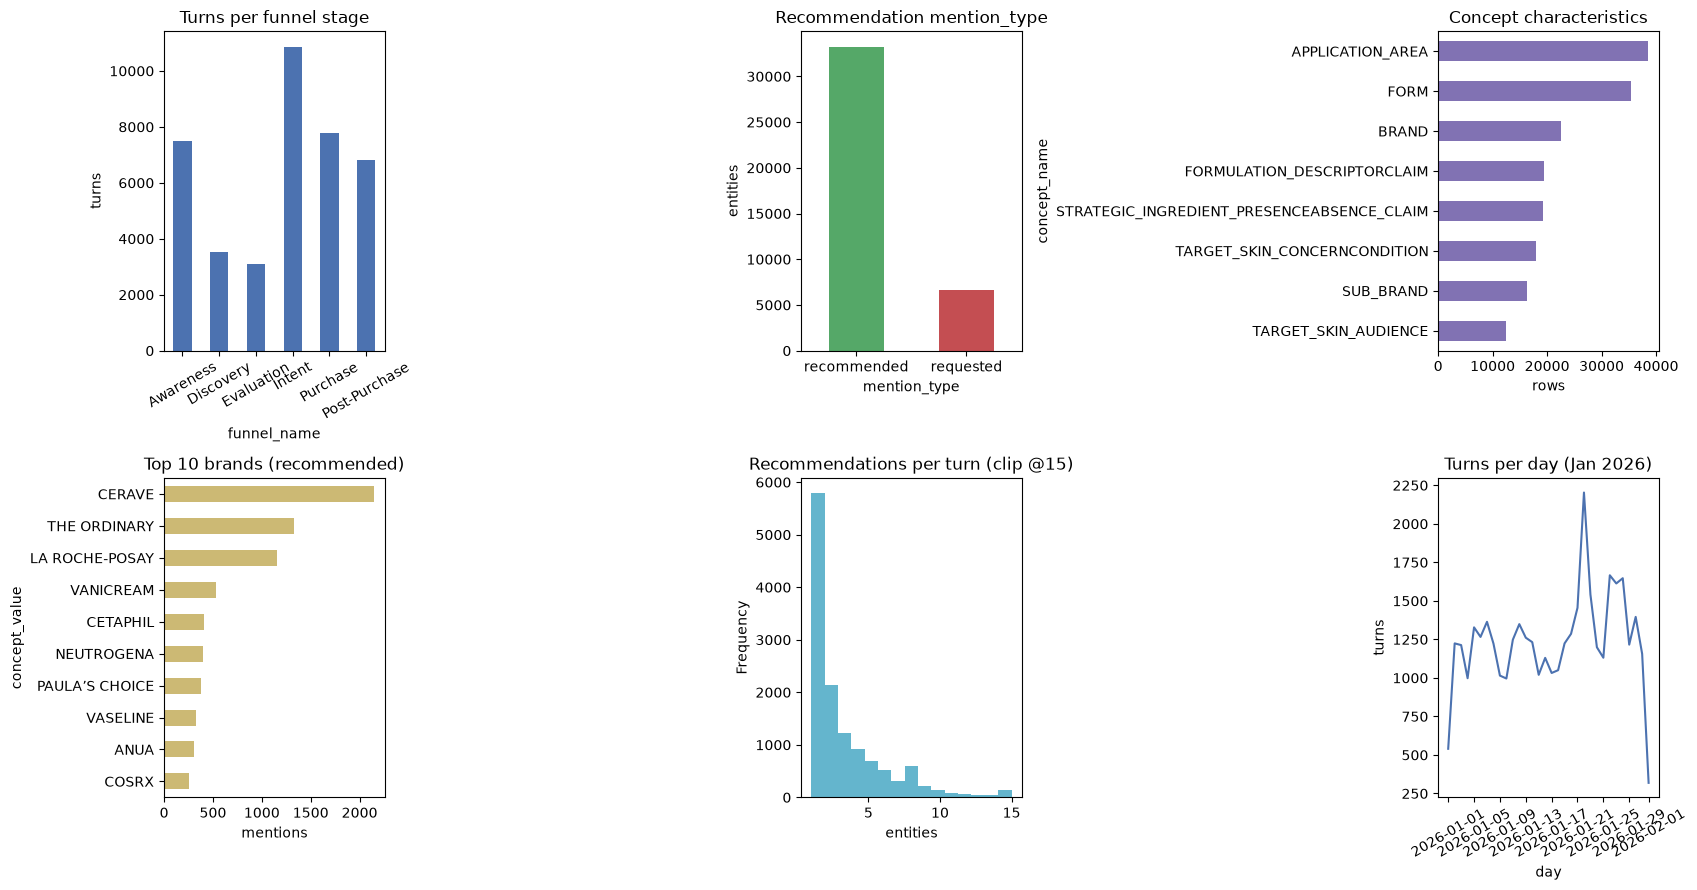

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(17, 9))

# funnel stage distribution (ordered)
order = ["Awareness", "Discovery", "Evaluation", "Intent", "Purchase", "Post-Purchase"]
fj = funnel.merge(dim_funnel[["funnel_id", "funnel_name"]], on="funnel_id")
fj["funnel_name"].value_counts().reindex(order).plot.bar(ax=ax[0, 0], color="#4C72B0")
ax[0, 0].set(title="Turns per funnel stage", ylabel="turns"); ax[0, 0].tick_params(axis="x", rotation=30)

# mention type
recommendation["mention_type"].value_counts().plot.bar(ax=ax[0, 1], color=["#55A868", "#C44E52"])
ax[0, 1].set(title="Recommendation mention_type", ylabel="entities"); ax[0, 1].tick_params(axis="x", rotation=0)

# concept name counts
concept["concept_name"].value_counts().iloc[::-1].plot.barh(ax=ax[0, 2], color="#8172B3")
ax[0, 2].set(title="Concept characteristics", xlabel="rows")

# top brands
concept.loc[concept.concept_name == "BRAND", "concept_value"].value_counts().head(10).iloc[::-1].plot.barh(
    ax=ax[1, 0], color="#CCB974")
ax[1, 0].set(title="Top 10 brands (recommended)", xlabel="mentions")

# recommendations per turn
recommendation.groupby("message_id").size().clip(upper=15).plot.hist(bins=15, ax=ax[1, 1], color="#64B5CD")
ax[1, 1].set(title="Recommendations per turn (clip @15)", xlabel="entities")

# daily turn volume
st = search_turn.assign(day=pd.to_datetime(search_turn["question_ts"], unit="ms").dt.date)
st.groupby("day").size().plot(ax=ax[1, 2], color="#4C72B0")
ax[1, 2].set(title="Turns per day (Jan 2026)", ylabel="turns"); ax[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

## 10 · Notes & data-quality callouts
- **Concept linkage** is `fact_id → recommendation_id` (100% coverage), **not** `message_id` as the
  data dictionary states. To attach concepts to a turn, go through `fact_ai_recommendation`.
- **`mention_type`** values are `requested` / `recommended`; ~83% of extracted entities are LLM
  recommendations, ~17% are user requests.
- **`fact_ai_funnel`** is one assigned stage + score per turn (not a score per stage). The
  `Irrelevant (-1)` stage is defined in `dim_ai_funnel` but unused in this sample.
- **Scope of a turn:** ~32% of turns name at least one entity; every turn has a funnel stage and a
  question/answer topic; session topics are keyed by `session_id` in the `message_id` column.
- **Single service / market:** `service_id` (ChatGPT) and `service_market_id` (10340) are constant.
- **Timestamps** are Unix epoch **milliseconds**, spanning **Jan 2026**. A few `dim_ai_topic` values
  contain raw typos (e.g. *"fitnes"*, *"sinusiti"*).
- A small fraction (~1%) of `fact_ai_recommendation.message_id` values have no matching search turn
  (orphan recommendations).

In [13]:
recommendation

,recommendation_id,message_id,mention_type,rank,entity_context,service_market_id
0,4c78c952-638e-4e8a-b1b0-7d40fac7699a,b3f0dc8f55a3fe1bd95e601fff144723,requested,1,"La Roche-Posay Cicaplast B5 Serum, a facial hydrating serum used for barrier repair an...",10340
1,4cf28cae-0e91-4c53-91b5-73b8bcd1a34b,f72dcb8cbff5018bde75a8e123dfec7a,recommended,1,"Beauty of Joseon Centella Asiatica Calming Mask, a Korean facial sheet mask for hydrat...",10340
2,c80dabe5-8c84-4040-8f03-c6afbbd5b107,45b8d0c8dc9c5d8db460c5f215a15d58,recommended,1,"Beauty of Joseon Centella Asiatica Calming Mask, a Korean facial sheet mask for hydrat...",10340
3,09a7aa73-ae41-4985-bb3a-bc07a781abb6,45b8d0c8dc9c5d8db460c5f215a15d58,recommended,2,"Dr. Jart+ Ceramidin Skin Barrier Moisturizing Mask, a facial sheet mask for barrier re...",10340
4,0cab3b5e-e1b6-4abb-9ff3-d87b3b8739c8,f72dcb8cbff5018bde75a8e123dfec7a,recommended,2,"Dr. Jart+ Dermask Soothing Hydra Solution Pro, a facial sheet mask for soothing irrita...",10340
...,...,...,...,...,...,...
39874,05106d51-44a6-40a4-98b0-705f5fdd03ee,c01764b9-8f95-b968-ae72-ca7737f361f9,recommended,3,Oral doxycycline used in acne treatment planning for inflamed facial acne.,10340
39875,0b405cb9-ea43-4722-b35f-508c5539c330,c01764b9-8f95-b968-ae72-ca7737f361f9,recommended,4,Oral isotretinoin used for severe or scarring facial acne that fails standard treatment.,10340
39876,de122787-68e7-4272-a3e1-900d05c28bda,c01764b9-8f95-b968-ae72-ca7737f361f9,recommended,5,"TCA CROSS facial acne scar treatment for ice-pick pits, discussed as part of a scar-re...",10340
39877,40d7e278-5c0c-4a4e-a743-8640fd0fd086,c01764b9-8f95-b968-ae72-ca7737f361f9,recommended,6,"RF microneedling facial treatment for acne scars and texture improvement, suggested af...",10340
